<a href="https://colab.research.google.com/github/Michael2004-ukpeh/ml-playground/blob/master/XOR_Problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as  pd
from torch.utils.data import TensorDataset, random_split
import matplotlib.pyplot as plt

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


# Generate XOR Dataset

In [ ]:

np.random.seed(0)
X = np.vstack([
    np.random.randn(250, 2) * 0.5 + [-1, -1],
    np.random.randn(250, 2) * 0.5 + [-1,  1],
    np.random.randn(250, 2) * 0.5 + [ 1, -1],
    np.random.randn(250, 2) * 0.5 + [ 1,  1],
])
y = np.array([0]*250 + [1]*250 + [1]*250 + [0]*250)
df = pd.DataFrame(X, columns=['x1', 'x2'])
df['y'] = y
df

,x1,x2,y
0,-0.117974,-0.799921,0
1,-0.510631,0.120447,0
2,-0.066221,-1.488639,0
3,-0.524956,-1.075679,0
4,-1.051609,-0.794701,0
...,...,...,...
995,1.671311,0.630032,0
996,1.657569,0.838271,0
997,1.098914,1.048875,0
998,1.700762,1.079217,0


# Change numpy array into tensor

In [ ]:
X= torch.from_numpy(X)
y = torch.from_numpy(y)
X, y

(tensor([[-0.1180, -0.7999],
         [-0.5106,  0.1204],
         [-0.0662, -1.4886],
         ...,
         [ 1.0989,  1.0489],
         [ 1.7008,  1.0792],
         [ 0.4290,  0.3445]], dtype=torch.float64),
 tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

# Ensure X and y are in the right datatype and split data

In [ ]:
X = X.float()
y =y.float()

# Create a TensorDataset
dataset = TensorDataset(X, y)


# Define the split ratio
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

# Split the dataset
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

print(f"Training dataset size: {len(train_dataset)}")
print(f"Testing dataset size: {len(test_dataset)}")

Training dataset size: 800
Testing dataset size: 200


# Build XOR Network

In [ ]:
class SingleLayerXOR(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear = nn.Linear(2, 1)
    self.activation = nn.Sigmoid()

  def forward(self, x):
    x = self.linear(x)
    x = self.activation(x)
    return x

class XORWithHiddenLayer(nn.Module):
  def __init__(self):
    super().__init__()
    self.hidden = nn.Linear(2, 4) # Hidden layer with 4 neurons
    self.relu = nn.ReLU()
    self.output = nn.Linear(4,1) # Output layer
    self.sigmoid = nn.Sigmoid()

  def forward(self, x):
    x = self.hidden(x)
    x = self.relu(x)
    x = self.output(x) # Apply output layer
    x = self.sigmoid(x)
    return x

# Training Loop

In [ ]:
def train(model, X_train, y_train, X_test, y_test, optimizer=None, criterion=None, epochs=1000, lr=0.01):
    train_losses = []
    val_losses = []
    if optimizer is None:
      optimizer = torch.optim.SGD(model.parameters(),lr)
    if criterion is None:
      criterion =  nn.BCELoss()
    for epoch in range(epochs):
       # Zero_grad - clear previous gradients calculated by the autograd
      optimizer.zero_grad()
      # Make prediction
      y_pred_train = model(X_train)

      # Do backward calculation of gradient in backprop
      # gradient = X * dy*g'(x)

      loss_train = criterion(y_pred_train, y_train)
      train_losses.append(loss_train.item())
      loss_train.backward()

      # Tune parameters
      optimizer.step()

      # Calculate validation loss
      # Set model to evaluation mode
      model.eval()
      with torch.no_grad():
          y_pred_val = model(X_test)
          loss_val = criterion(y_pred_val, y_test)
          val_losses.append(loss_val.item())
      # Set model back to training mode
      model.train()

      if epoch % 100 == 0:
        print(f"Epoch: {epoch}, Train Loss: {loss_train.item():.4f}, Val Loss: {loss_val.item():.4f}")
    return model, train_losses, val_losses

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, dataset, name="Model"):
  # Set the model to evaluation mode
    model.eval()
    # Get X from the dataset
    X_test = dataset[:][0].to(device)
    # Get Y from the dataset
    y_test = dataset[:][1].to(device)

    # Disable gradient calculation for evaluation
    with torch.no_grad():
        y_pred_proba = model(X_test)
        # Convert probabilities to binary predictions
        y_pred = (y_pred_proba >= 0.5).float()

    # Calculate test loss
    criterion = nn.BCELoss()
    test_loss = criterion(y_pred_proba, y_test.view(-1, 1).float()).item()

    # Move tensors to CPU and convert to numpy for sklearn metrics
    y_test_np = y_test.cpu().numpy()
    y_pred_np = y_pred.cpu().numpy()

    accuracy = accuracy_score(y_test_np, y_pred_np)
    precision = precision_score(y_test_np, y_pred_np)
    recall = recall_score(y_test_np, y_pred_np)
    f1 = f1_score(y_test_np, y_pred_np)

    print(f"\n--- {name} Evaluation ---")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    return accuracy, precision, recall, f1

In [ ]:

# Extract X_train, y_train, X_test, y_test from the datasets
X_train = train_dataset[:][0].to(device)
 # Reshape and ensure float for BCELoss
y_train = train_dataset[:][1].to(device).view(-1, 1).float()
X_test = test_dataset[:][0].to(device)
# Reshape and ensure float for BCELoss
y_test = test_dataset[:][1].to(device).view(-1, 1).float()

# Train and Evaluate SingleLayerXOR
print("\nStarting training for SingleLayerXOR...")
single_layer_model = SingleLayerXOR().to(device)
single_layer_optimizer = torch.optim.SGD(single_layer_model.parameters(), lr=0.01)
single_layer_criterion = nn.BCELoss()
single_layer_model, single_layer_train_losses, single_layer_val_losses = train(
    single_layer_model, X_train, y_train, X_test, y_test,
    optimizer=single_layer_optimizer,
    criterion=single_layer_criterion,
    epochs=10000
)
evaluate_model(single_layer_model, test_dataset, name="SingleLayerXOR")

#  Train and Evaluate XORWithHiddenLayer
print("\nStarting training for XORWithHiddenLayer...")
hidden_layer_model = XORWithHiddenLayer().to(device)
hidden_layer_optimizer = torch.optim.SGD(hidden_layer_model.parameters(), lr=0.01)
hidden_layer_criterion = nn.BCELoss()
hidden_layer_model, hidden_layer_train_losses, hidden_layer_val_losses = train(
    hidden_layer_model, X_train, y_train, X_test, y_test,
    optimizer=hidden_layer_optimizer,
    criterion=hidden_layer_criterion,
    epochs=10000
)
evaluate_model(hidden_layer_model, test_dataset, name="XORWithHiddenLayer")


Starting training for SingleLayerXOR...
Epoch: 0, Train Loss: 0.7730, Val Loss: 0.7494
Epoch: 100, Train Loss: 0.7405, Val Loss: 0.7234
Epoch: 200, Train Loss: 0.7205, Val Loss: 0.7085
Epoch: 300, Train Loss: 0.7087, Val Loss: 0.7005
Epoch: 400, Train Loss: 0.7018, Val Loss: 0.6967
Epoch: 500, Train Loss: 0.6979, Val Loss: 0.6950
Epoch: 600, Train Loss: 0.6956, Val Loss: 0.6945
Epoch: 700, Train Loss: 0.6943, Val Loss: 0.6945
Epoch: 800, Train Loss: 0.6935, Val Loss: 0.6947
Epoch: 900, Train Loss: 0.6931, Val Loss: 0.6950
Epoch: 1000, Train Loss: 0.6928, Val Loss: 0.6953
Epoch: 1100, Train Loss: 0.6927, Val Loss: 0.6955
Epoch: 1200, Train Loss: 0.6926, Val Loss: 0.6958
Epoch: 1300, Train Loss: 0.6925, Val Loss: 0.6959
Epoch: 1400, Train Loss: 0.6925, Val Loss: 0.6961
Epoch: 1500, Train Loss: 0.6925, Val Loss: 0.6962
Epoch: 1600, Train Loss: 0.6925, Val Loss: 0.6963
Epoch: 1700, Train Loss: 0.6925, Val Loss: 0.6963
Epoch: 1800, Train Loss: 0.6925, Val Loss: 0.6964
Epoch: 1900, Train Lo

(0.905, 0.9038461538461539, 0.912621359223301, 0.9082125603864735)

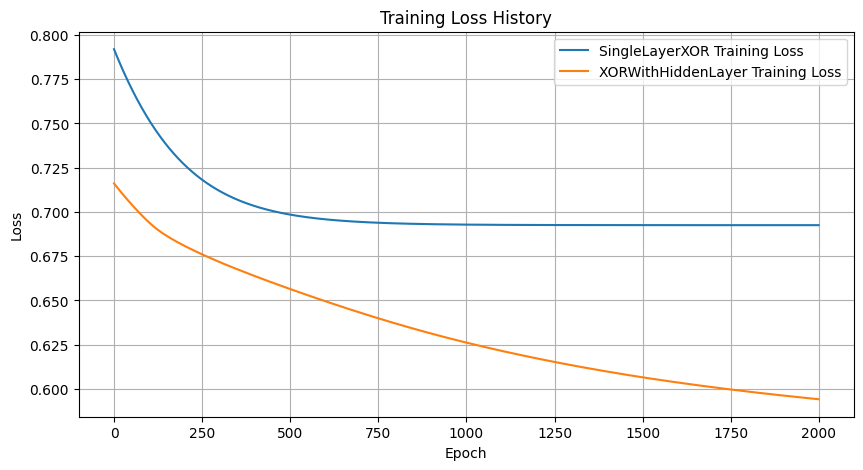

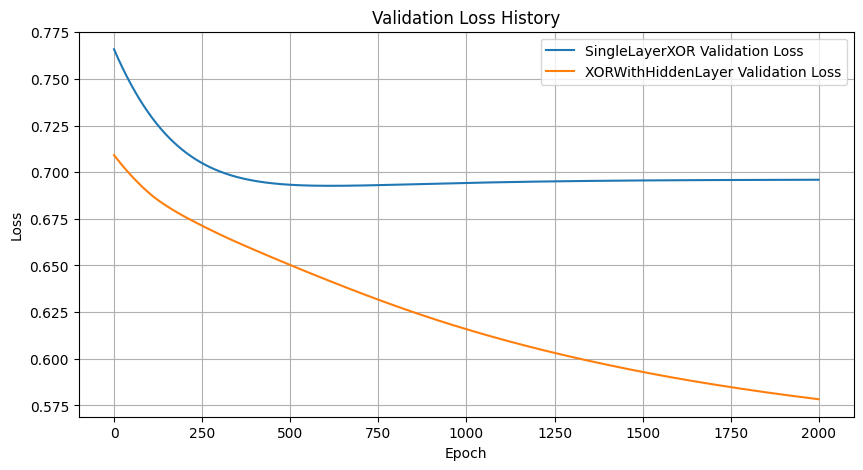

In [ ]:


# Plot Training Loss History
plt.figure(figsize=(10, 5))
plt.plot(single_layer_train_losses, label='SingleLayerXOR Training Loss')
plt.plot(hidden_layer_train_losses, label='XORWithHiddenLayer Training Loss')
plt.title('Training Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot Validation Loss History
plt.figure(figsize=(10, 5))
plt.plot(single_layer_val_losses, label='SingleLayerXOR Validation Loss')
plt.plot(hidden_layer_val_losses, label='XORWithHiddenLayer Validation Loss')
plt.title('Validation Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

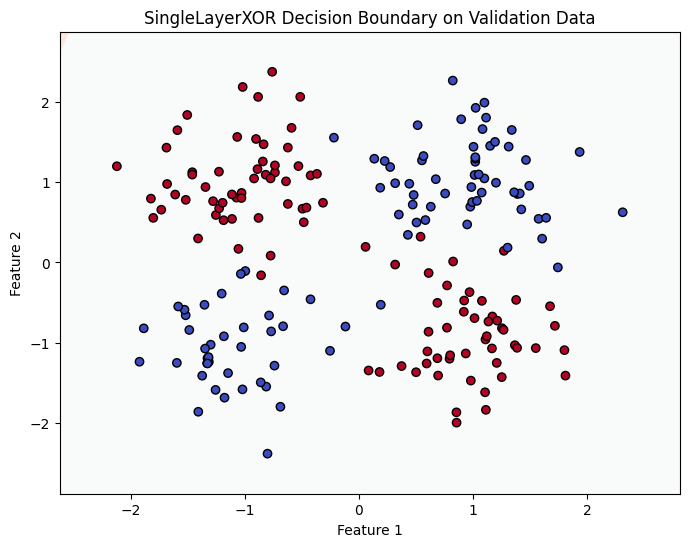

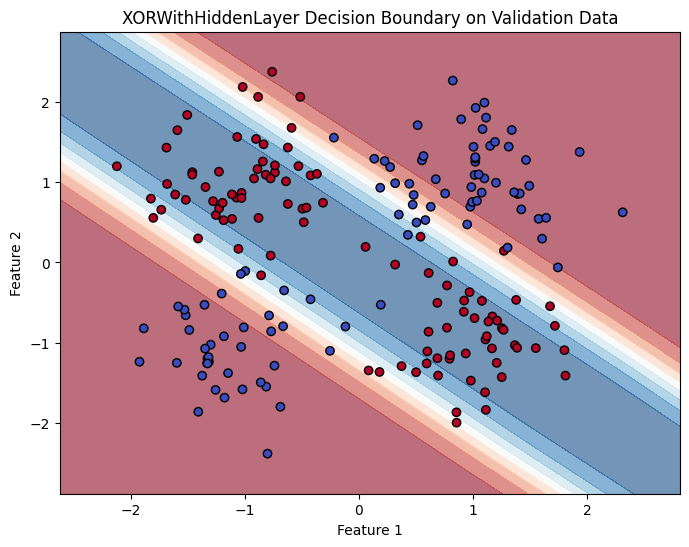

In [ ]:
def plot_decision_boundary(model, X, y, title):
    model.eval()
    X_np = X.cpu().numpy()
    y_np = y.cpu().numpy()

    x_min, x_max = X_np[:, 0].min() - 0.5, X_np[:, 0].max() + 0.5
    y_min, y_max = X_np[:, 1].min() - 0.5, X_np[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    grid_points = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32).to(device)
    with torch.no_grad():
        Z = model(grid_points).cpu().numpy().reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, levels=np.linspace(0, 1, 10), cmap='RdBu', alpha=0.6)
    plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, cmap='coolwarm', edgecolors='k', marker='o')
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    # plt.colorbar(label='Predicted Probability')
    plt.show()

# Plot decision boundaries on validation data (using X_test, y_test)
plot_decision_boundary(single_layer_model, X_test, y_test, 'SingleLayerXOR Decision Boundary on Validation Data')
plot_decision_boundary(hidden_layer_model, X_test, y_test, 'XORWithHiddenLayer Decision Boundary on Validation Data')

### Summary of Observations

**Training and Validation Loss Histories:**
*   **SingleLayerXOR:** The model is underfitting as it flatlines due to its inability to classify the data points
*   **XORWithHiddenLayer:** The loss for the model with a hidden layer decreases significantly and stabilizes at a much lower value. This shows the model bringing a nonlinear layer is able to help create proper decision boundaries across data points
**Decision Boundaries:**
*   **SingleLayerXOR:** The decision boundary for the single-layer model is a straight line due to its linear classification. This does not allow proper classification of data points
*   **XORWithHiddenLayer:** The decision boundary for the model with a hidden layer is non-linear and successfully separates the XOR data points into their respective classes as seen in the contour map.

**Overall Conclusion:**
XOR gate with a hidden layer  is better as a hidden layer allows for proper representation as 2 neurons move to 4 neurons and non-linearity is employed to help in classification